In [1]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)-8s %(name)s: %(message)s",
    datefmt="%H:%M:%S",
)

import tanglepack
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%load_ext autoreload
%autoreload 2

/mnt/c/Users/etccu/Documents/TanglePack/env/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
def henon_map(point):
    """
    Defines the henon map for binary horshoe parameters to test basic functionality
    """

    k, b = (2, 1)

    x = point[0]
    y = point[1]

    return np.array([y - k + x**2, -b * x])


def henon_map_inverse(point):
    """Defines the inverse henon map for"""

    k, b = (2, 1)

    x = point[0]
    y = point[1]

    return np.array([-y / b, x + k - (y**2) / (b**2)])


def henon_jacobian(point):
    """defines the jacobian for the henon map"""

    k, b = (2, 1)

    x = point[0]
    y = point[1]

    return np.array([[2 * x, 1], [-b, 0]])


In [3]:
henon = tanglepack.DynamicalSystem(henon_map, henon_map_inverse, henon_jacobian)
fp_solver = tanglepack.FixedPointSolver(henon)
man_maker = tanglepack.ManifoldInitializer(henon)
man_machine = tanglepack.ManifoldMachine(henon)

In [4]:
initial_guess = [[0, 1], [-1, 0], [-1, 1]]

fixed_point = fp_solver.construct_fixed_point(initial_guess, 2)

print(f"fixed point: {fixed_point.coordinates}")

eigenvalues: [0.26794919 3.73205081]
eigenvalues: [0.26794919 3.73205081]
eigenvalues: [3.73205081 0.26794919]
k value: 3
fixed point: [[-1.97042575e-12  1.00000000e+00]
 [-1.00000000e+00  0.00000000e+00]
 [-1.00000000e+00  1.00000000e+00]]


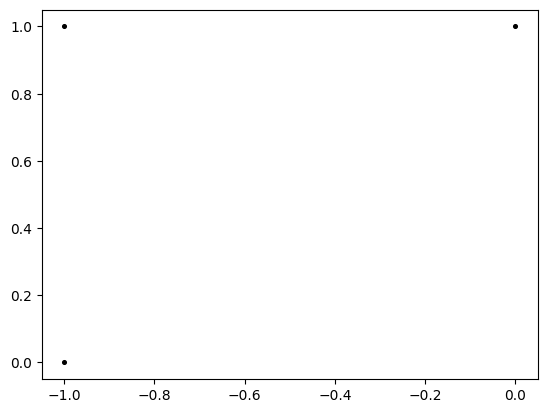

In [5]:
plt.figure()
plt.scatter(*fixed_point.coordinates[0], c="k", s=7)
plt.scatter(*fixed_point.coordinates[1], c="k", s=7)
plt.scatter(*fixed_point.coordinates[2], c="k", s=7)

Fixed Point: [-1.97042575e-12  1.00000000e+00]


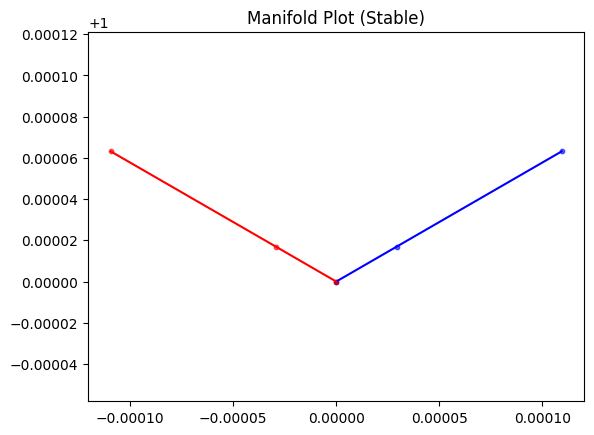

In [9]:
orbit_index = 0
print(f"Fixed Point: {fixed_point.coordinates[orbit_index]}")

initial_unstable_segment = man_maker.get_initial_fundamental_segment(
    fixed_point, orbit_index, 0, "unstable"
)
initial_stable_segment = man_maker.get_initial_fundamental_segment(
    fixed_point, orbit_index, 0, "stable"
)
plt.figure()
plt.scatter(*fixed_point.coordinates[orbit_index], c="k", s=7)
initial_unstable_segment.plot(color='blue', show_points=True)
initial_stable_segment.plot(color='red', show_points=True)

plt.show()

In [ ]:
period = 3

for orbit_index in range(period):

    print(f"Fixed Point: {fixed_point.coordinates[orbit_index]}")

    initial_unstable_segment = man_maker.get_initial_fundamental_segment(
        fixed_point, orbit_index, 0, "unstable"
    )
    initial_stable_segment = man_maker.get_initial_fundamental_segment(
        fixed_point, orbit_index, 0, "stable"
    )

    print(f"Branch {orbit_index} points: \n {initial_unstable_segment.get_point_array()}")

    # print(f"Mapped points: \n {henon.map(initial_unstable_segment.get_point_array())}")
    print(f"Mapped points: \n {np.array(list(map(henon.map, initial_unstable_segment.get_point_array())))}")

Fixed Point: [-1.97042575e-12  1.00000000e+00]
Branch 0 points: 
 [[-1.97042575e-12  1.00000000e+00]
 [ 2.93016127e-05  1.00001692e+00]
 [ 1.09383820e-04  1.00006315e+00]]
Mapped points: 
 [[-1.00000000e+00  1.97042575e-12]
 [-9.99983074e-01 -2.93016127e-05]
 [-9.99936835e-01 -1.09383820e-04]]
Difference between mapped and next
Fixed Point: [-1.  0.]
Branch 1 points: 
 [[-1.00000000e+00  0.00000000e+00]
 [-1.00001694e+00  2.92811094e-05]
 [-1.00006315e+00  1.09383822e-04]]
Mapped points: 
 [[-1.          1.        ]
 [-0.99993684  1.00001694]
 [-0.99976431  1.00006315]]
Difference between mapped and next
Fixed Point: [-1.  1.]
Branch 2 points: 
 [[-1.          1.        ]
 [-1.00003269  0.99999125]
 [-1.000122    0.99996731]]
Mapped points: 
 [[-1.51922919e-12  1.00000000e+00]
 [ 5.66222982e-05  1.00003269e+00]
 [ 2.11328200e-04  1.00012200e+00]]
Difference between mapped and next


In [60]:
initial_unstable_segment = man_maker.get_initial_fundamental_segment(
    fixed_point, 0, 0, "unstable"
)
initial_stable_segment = man_maker.get_initial_fundamental_segment(
    fixed_point, 0, 0, "stable"
)

print(f"poitns! {initial_unstable_segment.get_point_array()}")

unstable_manifold = initial_unstable_segment
stable_manifold = initial_stable_segment

# grow unstable manifold
num_iterations = 12
unstable_manifold = man_machine.grow_x_times(
    unstable_manifold, fixed_point, num_iterations
)

# grow stable manifold
num_iterations = 16
stable_manifold = man_machine.grow_x_times(stable_manifold, fixed_point, num_iterations)

# plt.figure()
# initial_unstable_segment.plot(show_points=True)
# plt.show()

plt.figure()

unstable_manifold.plot("blue")
stable_manifold.plot("red")
# plt.scatter(*fixed_point.coordinates[0], c="k", s=7)

# for point in tangle._intersecting_coords.values():
#     plt.scatter(*point, c="k", s=7, zorder=10)

# plt.xlim([-15, 15])
# plt.ylim([-15, 15])
plt.show()


12:06:17 INFO     tanglepack.ManifoldMachine: 0 Points added during refinement
12:06:17 INFO     tanglepack.ManifoldMachine: 2 NUMBER OF CURRENT POINTS


poitns! [[-1.97042575e-12  1.00000000e+00]
 [ 2.93016127e-05  1.00001692e+00]
 [ 1.09383820e-04  1.00006315e+00]]


AssertionError: 

Think about how cdists are computed when iterating with higher period orbits. Like it probably is not the same